In [1]:
#Importing CSV file and understand about dataset
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("fraud_detection_csv_dataset.csv")

In [2]:
#Data inspection
print(df.head(5),'\n')
print(df.shape,'\n')
print(df.columns,'\n')
print(df.dtypes,'\n')
print(df.info(),'\n')

#Data Cleaning
print(df.isnull().sum(),'\n')
print(df.duplicated().sum(),'\n')


   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0   

(6362620, 11) 

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       

isFraud
0    6354407
1       8213
Name: count, dtype: int64 

Fraud percentage : 0.13% 

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64 

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097 

count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64 



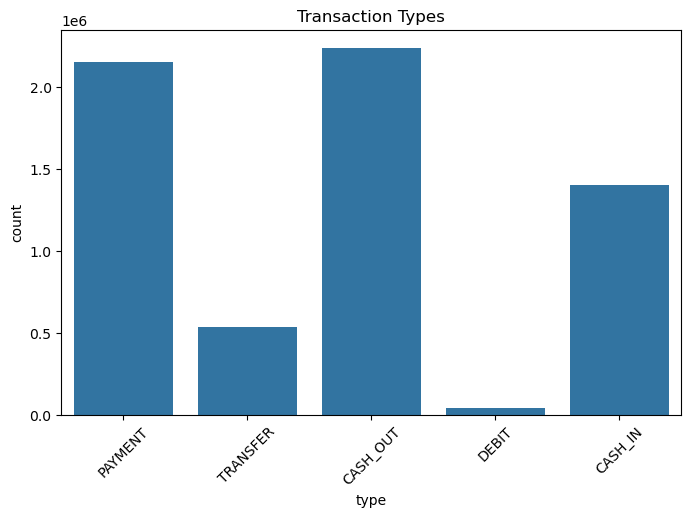

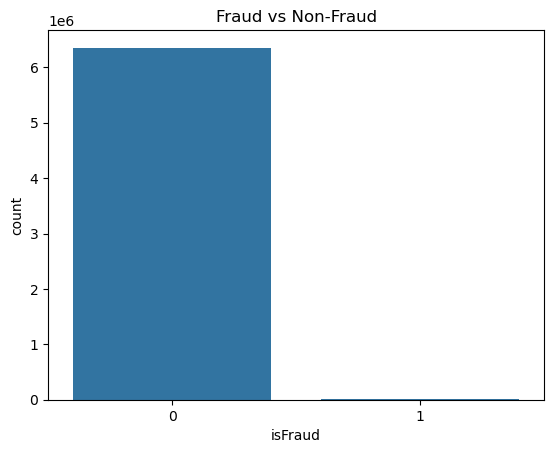

In [3]:
#Basic EDA

print(df['isFraud'].value_counts(),'\n')        #fraud count

fraud_percentage = (df['isFraud'].sum() / len(df)) * 100           #fraud percentage
print(f"Fraud percentage : {fraud_percentage:.2f}%" ,'\n')

print(df['type'].value_counts(),'\n')                        #Transaction Type Analysis

print(pd.crosstab(df['type'], df['isFraud']),'\n')             #Fraud by Transaction Type

print(df['amount'].describe(),'\n')                  #High Amount Transactions


#Visualize Transaction Types
plt.figure(figsize=(8,5))

sns.countplot(x='type', data=df)

plt.title("Transaction Types")

plt.xticks(rotation=45)

plt.show()


#Visualize Fraud Distribution
sns.countplot(x='isFraud', data=df)

plt.title("Fraud vs Non-Fraud")

plt.show()


In [4]:
#cleaned fraud data
df.to_csv("cleaned_fraud_data.csv", index=False)

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_fraud_data.csv")

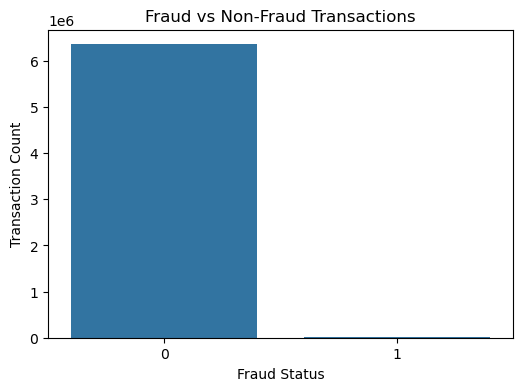

In [16]:
#Fraud vs Non-Fraud Count Plot
plt.figure(figsize=(6,4))

sns.countplot(x='isFraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.xlabel("Fraud Status")

plt.ylabel("Transaction Count")

plt.savefig("C:\Fraud Detection/visuals/fraud_vs_nonfraud.png")

plt.show()

#Insight:
#Fraud cases are very low
#Dataset is highly imbalanced

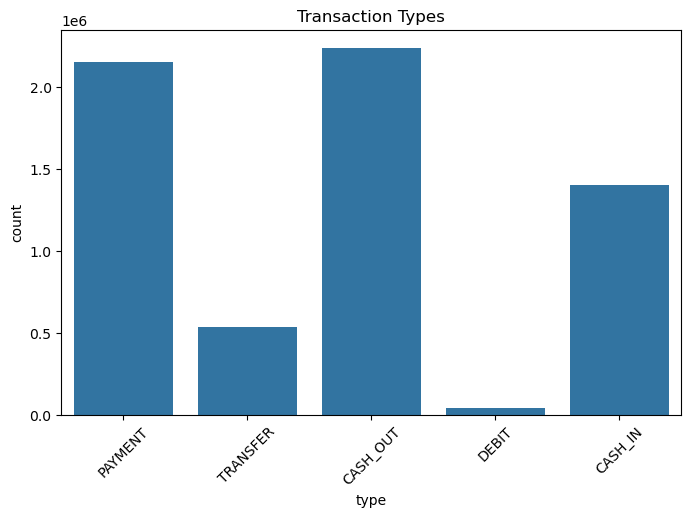

In [17]:
#Transaction Type Distribution
plt.figure(figsize=(8,5))

sns.countplot(x='type', data=df)

plt.title("Transaction Types")

plt.xticks(rotation=45)

plt.savefig("C:\Fraud Detection/visuals/transaction_types.png")


plt.show()

#This shows which transaction types occur most.

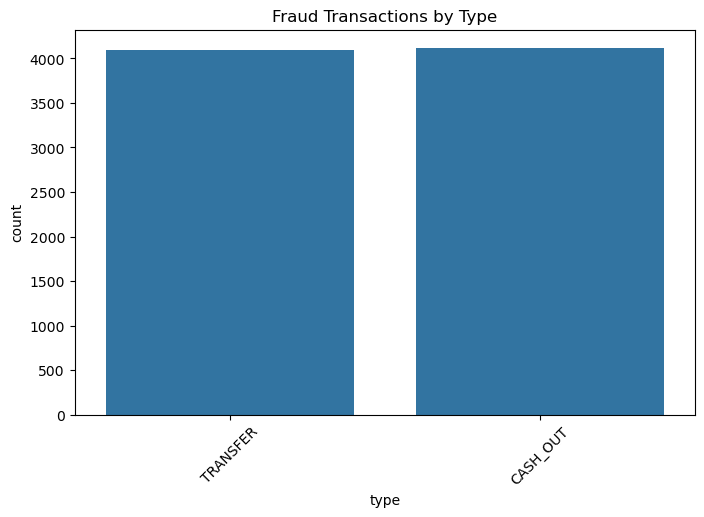

In [18]:
#Fraud by Transaction Type
fraud_df = df[df['isFraud'] == 1]

plt.figure(figsize=(8,5))

sns.countplot(x='type', data=fraud_df)

plt.title("Fraud Transactions by Type")

plt.xticks(rotation=45)

plt.savefig("C:\Fraud Detection/visuals/fraud_by_transaction_type.png")

plt.show()

#Important insight:
#Usually:
#TRANSFER
#CASH_OUT
#contain most frauds.


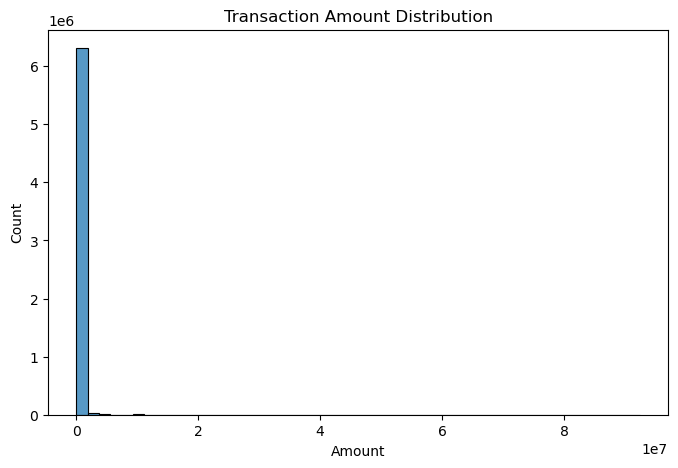

In [19]:
#Transaction Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['amount'], bins=50)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.savefig("C:\Fraud Detection/visuals/transaction_amount_distribution.png")

plt.show()

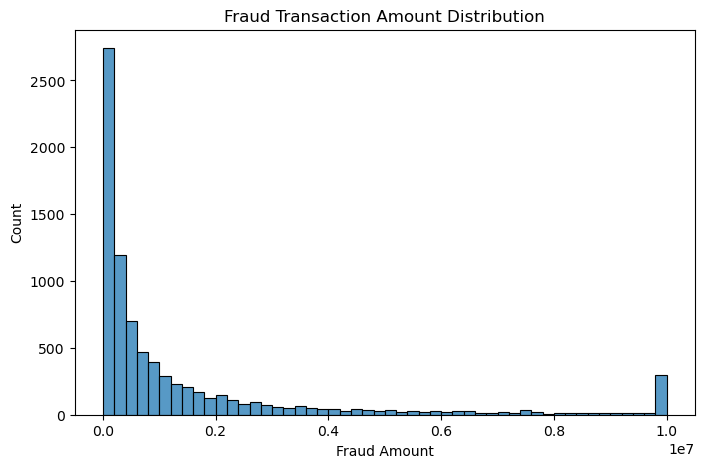

In [20]:
#Fraud Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(fraud_df['amount'], bins=50)

plt.title("Fraud Transaction Amount Distribution")

plt.xlabel("Fraud Amount")

plt.savefig("C:\Fraud Detection/visuals/fraud_amount_distribution.png")

plt.show()

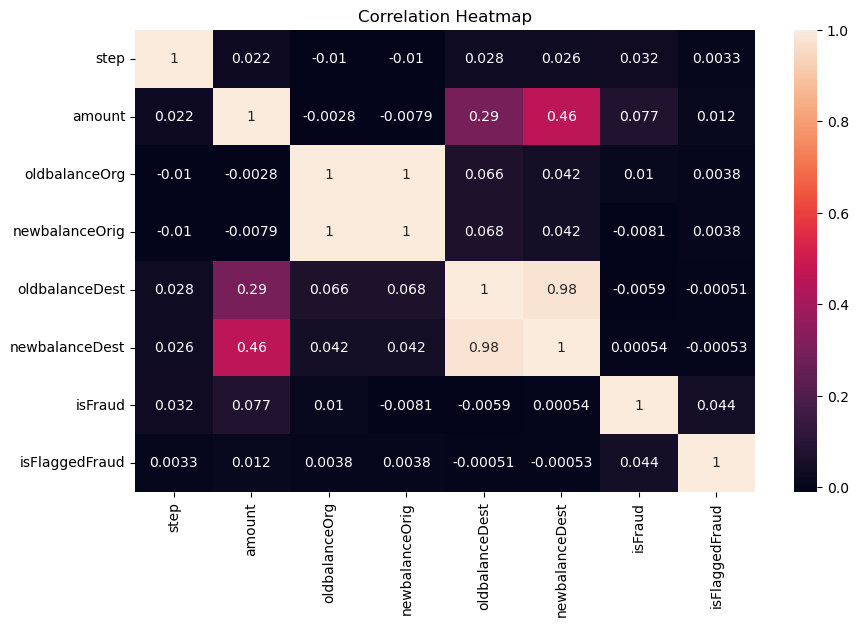

In [37]:
#Correlation Heatmap
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.savefig("C:\Fraud Detection/visuals/correlation_heatmap.png")

plt.show()

Dataset Loaded Successfully

Dataset Shape:
(50000, 11)

First 5 Rows:
         step      type      amount     nameOrig  oldbalanceOrg  \
3737323   278   CASH_IN   330218.42   C632336343       20866.00   
264914     15   PAYMENT    11647.08  C1264712553       30370.00   
85647      10   CASH_IN   152264.21  C1746846248      106589.00   
5899326   403  TRANSFER  1551760.63   C333676753           0.00   
2544263   206   CASH_IN    78172.30   C813403091     2921331.58   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
3737323       351084.42   C834976624       452419.57       122201.15        0   
264914         18722.92   M215391829            0.00            0.00        0   
85647         258853.21  C1607284477       201303.01        49038.80        0   
5899326            0.00  C1564353608      3198359.45      4750120.08        0   
2544263      2999503.88  C1091768874       415821.90       337649.60        0   

         isFlaggedFraud  
3737323      

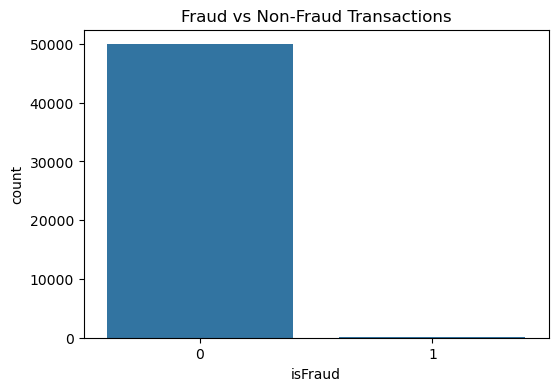

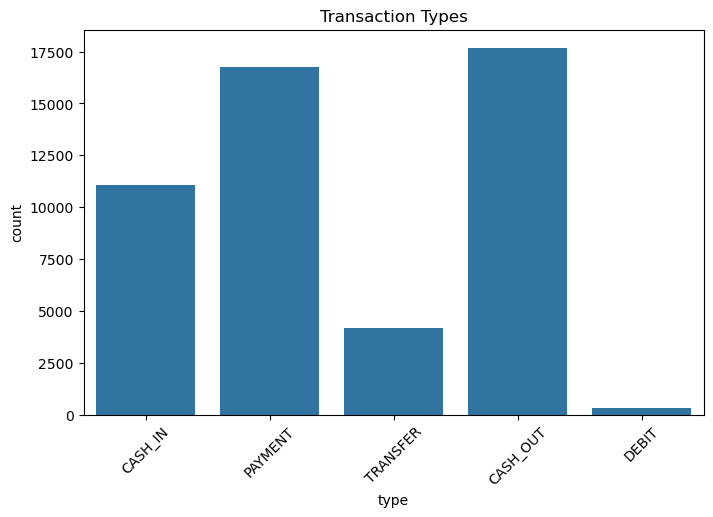


Training Shape: (40000, 11)
Testing Shape: (10000, 11)

After SMOTE:
isFraud
0    39945
1    39945
Name: count, dtype: int64

Random Forest Model Trained

Model Accuracy:
0.999

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9985
           1       0.63      0.80      0.71        15

    accuracy                           1.00     10000
   macro avg       0.82      0.90      0.85     10000
weighted avg       1.00      1.00      1.00     10000


Confusion Matrix:
[[9978    7]
 [   3   12]]


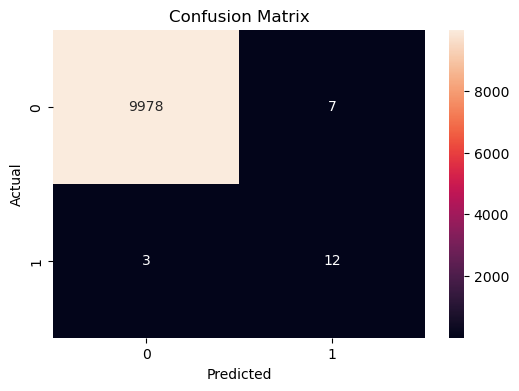


AUC Score:
0.9641528960106828


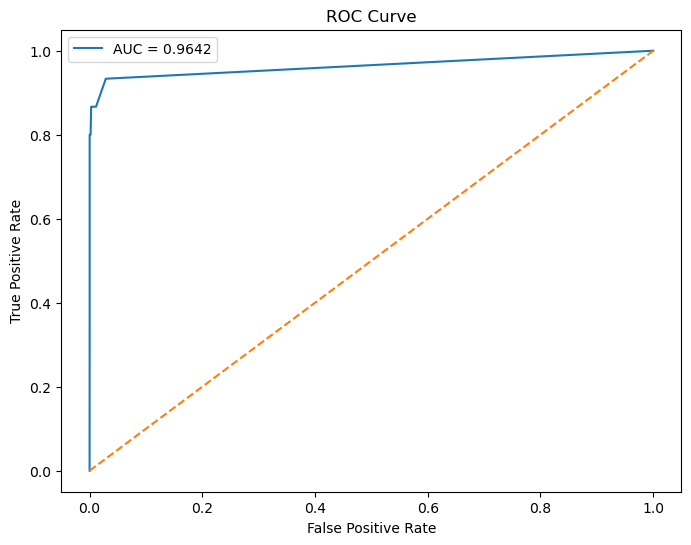


Top Features:
           Feature  Importance
2    oldbalanceOrg    0.268496
1           amount    0.172393
10   type_TRANSFER    0.155087
3   newbalanceOrig    0.098803
4   oldbalanceDest    0.072662
5   newbalanceDest    0.070425
9     type_PAYMENT    0.059630
0             step    0.052791
7    type_CASH_OUT    0.049708
8       type_DEBIT    0.000004


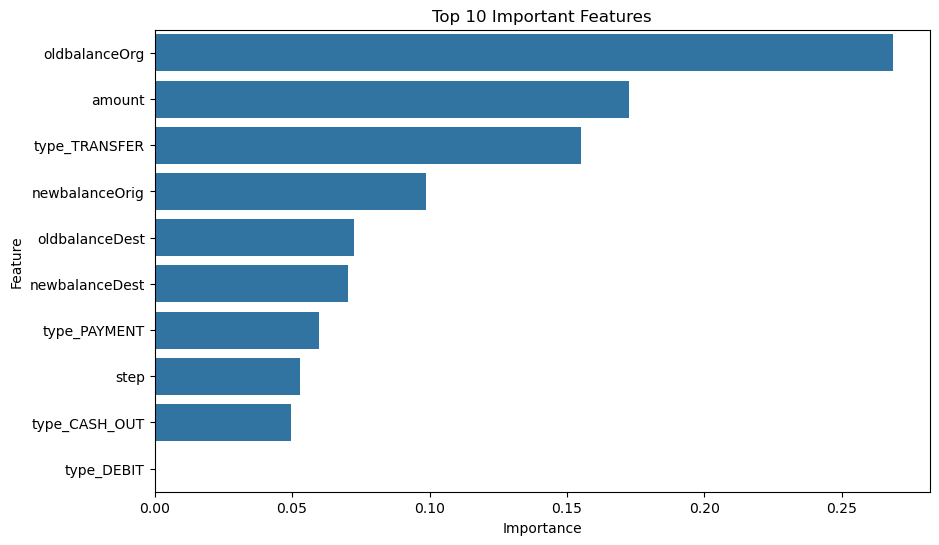


Running Isolation Forest...

Anomaly Detection Results:
anomaly
0    49900
1      100
Name: count, dtype: int64

FRAUD DETECTION PROJECT COMPLETED


In [40]:
# =====================================================
# FRAUD DETECTION PROJECT - FULL ML CODE
# WITHOUT SHAP
# =====================================================

# =====================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

# SMOTE
from imblearn.over_sampling import SMOTE

# Isolation Forest
from sklearn.ensemble import IsolationForest

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# =====================================================
# STEP 2: LOAD DATASET
# =====================================================

# Load only 50,000 rows for faster execution
df = pd.read_csv(
    "cleaned_fraud_data.csv"
).sample(50000, random_state=42)

print("Dataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# =====================================================
# STEP 3: CHECK MISSING VALUES
# =====================================================

print("\nMissing Values:")
print(df.isnull().sum())

# =====================================================
# STEP 4: FRAUD DISTRIBUTION
# =====================================================

print("\nFraud Distribution:")
print(df['isFraud'].value_counts())

# =====================================================
# STEP 5: FRAUD VISUALIZATION
# =====================================================

plt.figure(figsize=(6,4))

sns.countplot(x='isFraud', data=df)

plt.title("Fraud vs Non-Fraud Transactions")

plt.show()

# =====================================================
# STEP 6: TRANSACTION TYPE VISUALIZATION
# =====================================================

plt.figure(figsize=(8,5))

sns.countplot(x='type', data=df)

plt.title("Transaction Types")

plt.xticks(rotation=45)

plt.show()

# =====================================================
# STEP 7: CONVERT CATEGORICAL DATA
# =====================================================

df = pd.get_dummies(
    df,
    columns=['type'],
    drop_first=True
)

# =====================================================
# STEP 8: FEATURES AND TARGET
# =====================================================

X = df.drop([
    'isFraud',
    'nameOrig',
    'nameDest'
], axis=1)

y = df['isFraud']

# =====================================================
# STEP 9: TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

# =====================================================
# STEP 10: APPLY SMOTE
# =====================================================

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")

print(y_train_smote.value_counts())

# =====================================================
# STEP 11: TRAIN RANDOM FOREST MODEL
# =====================================================

rf_model = RandomForestClassifier(
    n_estimators=20,
    random_state=42
)

rf_model.fit(
    X_train_smote,
    y_train_smote
)

print("\nRandom Forest Model Trained")

# =====================================================
# STEP 12: MAKE PREDICTIONS
# =====================================================

y_pred = rf_model.predict(X_test)

# =====================================================
# STEP 13: MODEL EVALUATION
# =====================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nModel Accuracy:")

print(accuracy)

print("\nClassification Report:")

print(classification_report(
    y_test,
    y_pred
))

# =====================================================
# STEP 14: CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# =====================================================
# STEP 15: ROC CURVE & AUC SCORE
# =====================================================

y_prob = rf_model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("\nAUC Score:")

print(auc_score)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# =====================================================
# STEP 16: FEATURE IMPORTANCE
# =====================================================

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Features:")

print(feature_importance.head(10))

# =====================================================
# STEP 17: FEATURE IMPORTANCE PLOT
# =====================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

# =====================================================
# STEP 18: ISOLATION FOREST
# =====================================================

print("\nRunning Isolation Forest...")

# Create copy
iso_df = df.copy()

# Remove string columns
iso_df = iso_df.drop(
    ['nameOrig', 'nameDest', 'isFraud'],
    axis=1
)

# Create Isolation Forest model
iso_model = IsolationForest(
    n_estimators=50,
    contamination=0.002,
    random_state=42
)

# Train model
iso_model.fit(iso_df)

# Predict anomalies
iso_df['anomaly'] = iso_model.predict(iso_df)

# Convert labels
# 1 = normal
# -1 = anomaly

iso_df['anomaly'] = iso_df['anomaly'].map({
    1: 0,
    -1: 1
})

# Display anomaly results
print("\nAnomaly Detection Results:")

print(iso_df['anomaly'].value_counts())

# =====================================================
# FINAL MESSAGE
# =====================================================

print("\n=================================")

print("FRAUD DETECTION PROJECT COMPLETED")

print("=================================")

Generating SHAP Values...
SHAP values shape: (200, 11, 2)


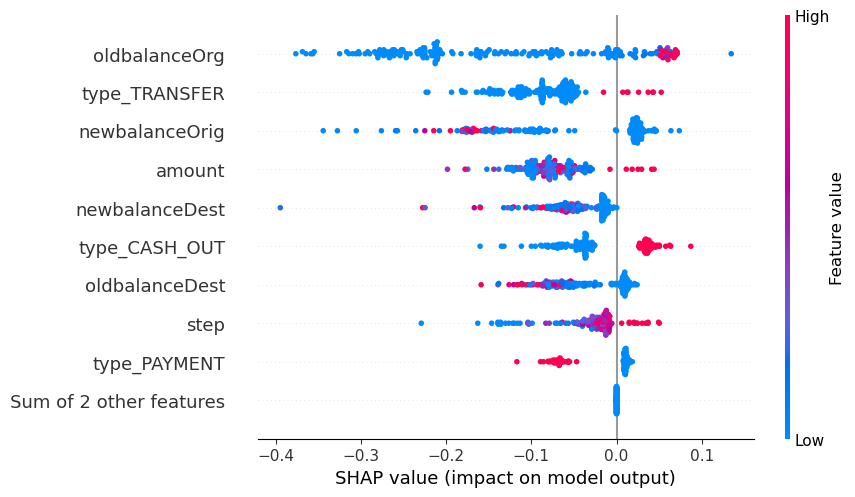

In [43]:
# =====================================================
# SHAP EXPLAINABILITY - CORRECT FULL CODE
# =====================================================

import shap

print("Generating SHAP Values...")

# -----------------------------------------------------
# 1. Take a small sample for faster SHAP computation
# -----------------------------------------------------
X_sample = X_test.sample(200, random_state=42)

# -----------------------------------------------------
# 2. Create SHAP TreeExplainer (works for tree models)
# -----------------------------------------------------
explainer = shap.TreeExplainer(rf_model)

# -----------------------------------------------------
# 3. Generate SHAP values for the sample data
#    NOTE: For classification models, output shape is:
#    (samples, features, classes)
# -----------------------------------------------------
shap_values = explainer(X_sample)

# -----------------------------------------------------
# 4. Check shape (optional but useful for debugging)
# -----------------------------------------------------
print("SHAP values shape:", shap_values.values.shape)

# -----------------------------------------------------
# 5. Select correct class for explanation
#    Usually:
#    - index 0 → class 0
#    - index 1 → class 1 (positive class)
# -----------------------------------------------------
class_index = 1

# -----------------------------------------------------
# 6. SHAP Beeswarm Plot (Feature Impact Overview)
# -----------------------------------------------------
shap.plots.beeswarm(
    shap_values[:, :, class_index],
    max_display=10
)